# Project 3 – Computing in Context  
### School Safety in New York City (2016–2017)

**Dataset(s) to be used:**  https://data.cityofnewyork.us/Education/2017-2018-Schools-NYPD-Crime-Data-Report/kwvk-z7i9/about_data
2016–2017 School Safety Report (NYC Open Data)  
Contains building-level data on school locations, borough, enrollment bands, and the number of major crimes, violent incidents, property crimes, and other incidents reported during the school year.

**Analysis question:**  
How do school safety outcomes vary across different parts of New York City?  
More specifically:

1. How do the numbers of major, violent, property, and other incidents differ across boroughs?  
2. Are buildings that host multiple schools more likely to experience higher numbers of incidents per school?  
3. Do certain geographical areas (e.g., Census Tracts or Community Boards) experience disproportionately higher incident counts?

**Columns that will (likely) be used:**
- `borough`
- `major_n`
- `oth_n`
- `prop_n`
- `nocrrim_n` 
- `vio_n`
- `avgofmajor_n`
- `avgofvio_n`
- `schools_in_building`
- `geocoded_column` 
- `census_tract`
- `community_board`
- `rangea` 



**Hypothesis:**  
School safety outcomes differ across NYC boroughs. I expect schools in the Bronx and parts of Brooklyn to report higher numbers of major and violent incidents on average, while Manhattan and Staten Island may show lower incident counts. I also expect buildings that serve multiple schools to report more incidents per building, possibly due to higher student density and shared facilities.


In [3]:
import pandas as pd
import numpy as np
import plotly.express as px


In [20]:
import matplotlib.pyplot as plt


In [25]:
import plotly.io as pio
pio.renderers.default = "vscode"


In [12]:
import sys

# install kaleido so that plotly can export PNG images
!{sys.executable} -m pip install -U kaleido


  Using cached pluggy-1.6.0-py3-none-any.whl.metadata (4.8 kB)
Using cached pluggy-1.6.0-py3-none-any.whl (20 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [kaleido]m6/9 [choreographer]

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [13]:
import plotly.io as pio

# use PNG images instead of the notebook/iframe mime renderer
pio.renderers.default = "png"


In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.io as pio


pio.renderers.default = "notebook"   


# **Data Cleaning & Transformation**

Before conducting analysis, several important cleaning steps were required:

### **1. Standardizing column names**

All column names were stripped of spaces, converted to lowercase, and special characters were replaced with underscores.

### **2. Converting incident counts to numeric**

Columns such as `major_n`, `vio_n`, `prop_n`, and `oth_n` were stored as text.
These were converted using `pd.to_numeric(..., errors="coerce")`.

### **3. Creating new derived metrics**

I engineered three key variables:

* **total_incidents** = sum of major, violent, property, and other incidents
* **violent_rate** = violent incidents / total incidents
* **major_rate** = major crimes / total incidents

These new variables allow more meaningful comparisons between schools.

In [4]:
df = pd.read_csv("2017_-_2018_Schools_NYPD_Crime_Data_Report_20251122.csv")
df.head()


,ID,Building Code,DBN,Location Name,Location Code,Address,Borough,Geographical District Code,Register,Building Name,...,Prop N,Vio N,ENGroupA,RangeA,AvgOfMajor N,AvgOfOth N,AvgOfNoCrim N,AvgOfProp N,AvgOfVio N,New Georeferenced Column
0,646,M019,01M301,"TECHNOLOGY,ARTS,AND SCIENCES STUDIO(MANHATTAN)",M301,185 FIRST AVENUE,M,1,99,185 FIRST AVENUE CONSOLIDATED LOCATION,...,NaN,NaN,2C,1-250,NaN,NaN,NaN,NaN,NaN,POINT (-74.329275 43.055092)
1,894,M389,05M357,SUCCESS ACADEMY HARLEM CENTRAL(MN),M357,461 West 131 Street,M,5,135,NaN,...,0.0,0.0,2C,1-250,0.25,0.88,1.69,0.57,0.45,POINT (-86.190823 43.243957)
2,71,K052,22K052,PS 52(BROOKLYN),K052,2675 EAST 29 STREET,K,22,757,NaN,...,2.0,0.0,5C,751-1000,0.38,1.52,3.88,0.83,0.91,POINT (-73.940627 40.588314)
3,"1,039",Q008,28Q008,J.H.S. 008 Richard S. Grossley,Q008,108-35 167 STREET,Q,28,336,108-35 167 STREET CONSOLIDATED LOCATION,...,NaN,NaN,3C,251-500,NaN,NaN,NaN,NaN,NaN,POINT (-73.786934 40.696766)
4,809,M149,75M162,P162(MN),M162,34 West 118th St.,M,75,SCHOOL CLOSED,34 West 118th St.,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-76.494659 38.97835)


In [5]:
df.info()
df.columns



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1919 entries, 0 to 1918
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          1919 non-null   object 
 1   Building Code               1919 non-null   object 
 2   DBN                         1646 non-null   object 
 3   Location Name               1919 non-null   object 
 4   Location Code               1650 non-null   object 
 5   Address                     1919 non-null   object 
 6   Borough                     1919 non-null   object 
 7   Geographical District Code  1919 non-null   int64  
 8   Register                    1919 non-null   object 
 9   Building Name               1017 non-null   object 
 10  # Schools                   1919 non-null   int64  
 11  Schools in Building         1919 non-null   object 
 12  Major N                     1175 non-null   float64
 13  Oth N                       1175 

Index(['ID', 'Building Code', 'DBN', 'Location Name', 'Location Code',
       'Address', 'Borough', 'Geographical District Code', 'Register',
       'Building Name', '# Schools', 'Schools in Building', 'Major N', 'Oth N',
       'NoCrim N', 'Prop N', 'Vio N', 'ENGroupA', 'RangeA', 'AvgOfMajor N',
       'AvgOfOth N', 'AvgOfNoCrim N', 'AvgOfProp N', 'AvgOfVio N',
       'New Georeferenced Column'],
      dtype='object')

In [7]:

df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
      .str.replace("#", "num")
)

df.columns


Index(['id', 'building_code', 'dbn', 'location_name', 'location_code',
       'address', 'borough', 'geographical_district_code', 'register',
       'building_name', 'num_schools', 'schools_in_building', 'major_n',
       'oth_n', 'nocrim_n', 'prop_n', 'vio_n', 'engroupa', 'rangea',
       'avgofmajor_n', 'avgofoth_n', 'avgofnocrim_n', 'avgofprop_n',
       'avgofvio_n', 'new_georeferenced_column'],
      dtype='object')

In [8]:
crime_cols = [
    "major_n", "oth_n", "nocrim_n", "prop_n", "vio_n",
    "avgofmajor_n", "avgofoth_n", "avgofnocrim_n",
    "avgofprop_n", "avgofvio_n"
]

for col in crime_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df[crime_cols].head()


,major_n,oth_n,nocrim_n,prop_n,vio_n,avgofmajor_n,avgofoth_n,avgofnocrim_n,avgofprop_n,avgofvio_n
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.0,0.0,3.0,0.0,0.0,0.25,0.88,1.69,0.57,0.45
2,1.0,1.0,0.0,2.0,0.0,0.38,1.52,3.88,0.83,0.91
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
df["total_incidents"] = df[["major_n", "oth_n", "nocrim_n", "prop_n", "vio_n"]].sum(axis=1)
df["total_incidents"].head()


0    0.0
1    3.0
2    4.0
3    0.0
4    0.0
Name: total_incidents, dtype: float64

In [13]:
df["violent_rate"] = df["vio_n"] / df["total_incidents"]
df["major_rate"]   = df["major_n"] / df["total_incidents"]

df[["total_incidents", "violent_rate", "major_rate"]].head()


,total_incidents,violent_rate,major_rate
0,0.0,NaN,NaN
1,3.0,0.0,0.00
2,4.0,0.0,0.25
3,0.0,NaN,NaN
4,0.0,NaN,NaN


**Borough-Level Analysis**

## **Total Incidents by Borough**

The first bar chart aggregates `total_incidents` across the five boroughs.

### **Findings**

* **Brooklyn (K)** reports the highest total incidents (~2878).
* Followed by **Bronx (X)** with similarly high counts (~2724).
* **Manhattan (M)** and **Queens (Q)** show moderate levels.
* **Staten Island (R)** reports the lowest incidents.
**This supports the hypothesis that Brooklyn and the Bronx have higher overall school safety incidents.**


In [18]:
# Aggregate total incidents by borough
borough_totals = (
    df.groupby("borough")[["total_incidents"]]
      .sum()
      .reset_index()
)

borough_totals


,borough,total_incidents
0,K,2878.0
1,M,1845.0
2,Q,1526.0
3,R,546.0
4,X,2724.0


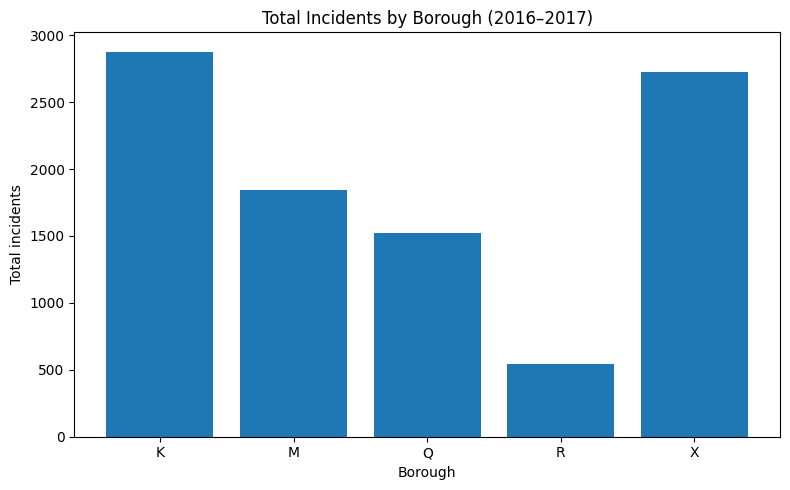

In [21]:
# Simple bar chart to compare safety across boroughs
plt.figure(figsize=(8, 5))

plt.bar(
    borough_totals["borough"],
    borough_totals["total_incidents"]
)

plt.title("Total Incidents by Borough (2016–2017)")
plt.xlabel("Borough")
plt.ylabel("Total incidents")

plt.tight_layout()
plt.show()



## **Incident Type Breakdown by Borough**

A stacked bar chart shows how types of incidents differ.

In [22]:
# 6. Incidents by type (major, violent, property, other) by borough
borough_types = (
    df.groupby("borough")[["major_n", "vio_n", "prop_n", "oth_n"]]
      .sum()
      .reset_index()
)

borough_types


,borough,major_n,vio_n,prop_n,oth_n
0,K,150.0,304.0,373.0,622.0
1,M,105.0,203.0,231.0,401.0
2,Q,72.0,178.0,179.0,325.0
3,R,17.0,77.0,58.0,130.0
4,X,111.0,330.0,236.0,518.0


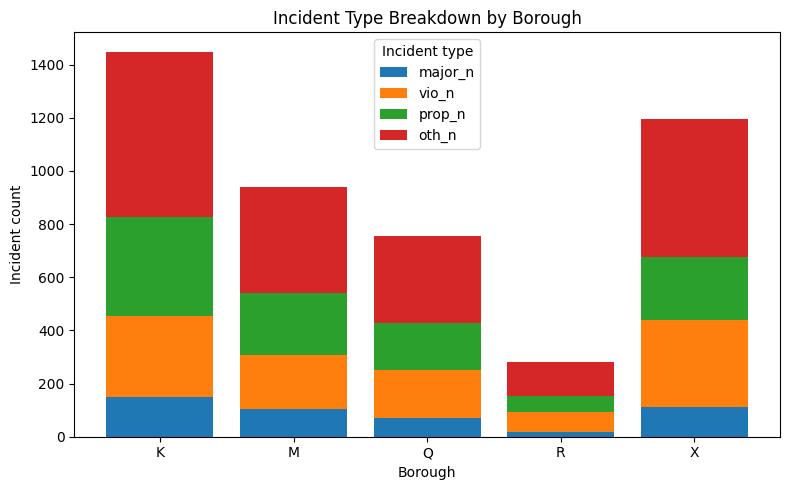

In [23]:
# Stacked bar chart to show the breakdown of incident types by borough
plt.figure(figsize=(8, 5))

bottom = np.zeros(len(borough_types))

for col in ["major_n", "vio_n", "prop_n", "oth_n"]:
    plt.bar(
        borough_types["borough"],
        borough_types[col],
        bottom=bottom,
        label=col
    )
    bottom += borough_types[col].values

plt.title("Incident Type Breakdown by Borough")
plt.xlabel("Borough")
plt.ylabel("Incident count")
plt.legend(title="Incident type")

plt.tight_layout()
plt.show()


<Figure size 800x500 with 0 Axes>

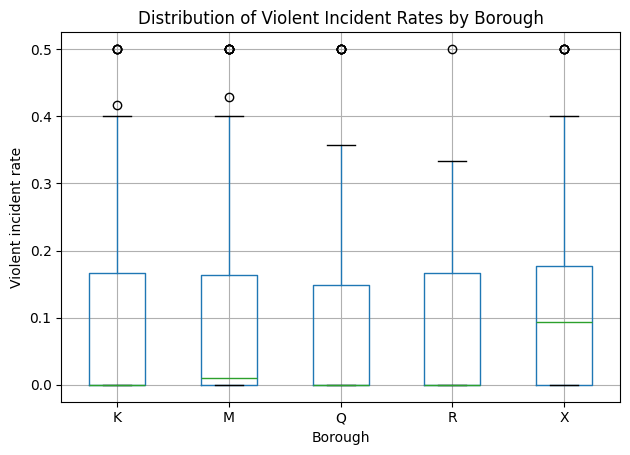

In [24]:
# 7. Distribution of violent incident rates by borough
plt.figure(figsize=(8, 5))

df.boxplot(
    column="violent_rate",
    by="borough"
)

plt.title("Distribution of Violent Incident Rates by Borough")
plt.suptitle("")  # Remove automatic 'violent_rate by borough' title
plt.xlabel("Borough")
plt.ylabel("Violent incident rate")

plt.tight_layout()
plt.show()


In [25]:
# 8. Does sharing a building with more schools relate to more incidents?

building_group = (
    df.groupby("schools_in_building")["total_incidents"]
      .mean()
      .reset_index()
      .sort_values("schools_in_building")
)

building_group


,schools_in_building,total_incidents
0,365 Beach 56 St,1.0
1,47 THE AMERICAN SIGN LANGUAGE & ENGLISH SECOND...,3.0
2,ABRAHAM LINCOLN HS(BS),39.0
3,ACAD FOR CAREERS IN TELEVISION & FILM(QN),3.0
4,ACADEMY FOR PERSONAL LEADERSHIP AND EXCELLENCE...,4.0
...,...,...
1171,YOUNG VOICES ACADEMY OF THE BRONX(XE),0.0
1172,YOUNG WOMEN LEADERSHIP SCHOOL ASTORIA(QUEENS),1.0
1173,YOUNG WOMEN LEADERSHIP SCHOOL QUEENS CAMPUS(QU...,18.0
1174,YOUNG WOMEN LEADERSHIP SCHOOL/MANHATTAN CAMPUS...,2.0


/var/folders/0q/76839ww105n5zrl0td7wppbw0000gn/T/ipykernel_45270/1713259850.py:12: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.



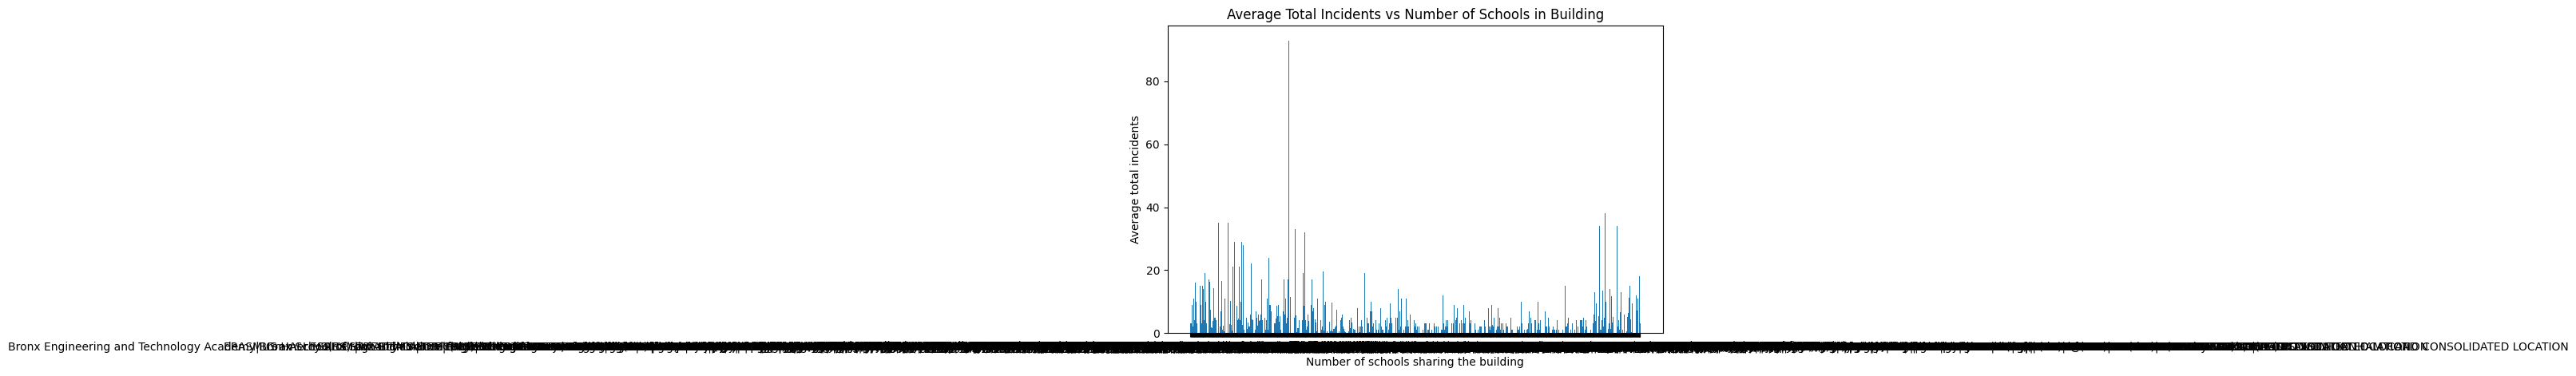

In [26]:
plt.figure(figsize=(8, 5))

plt.bar(
    building_group["schools_in_building"],
    building_group["total_incidents"]
)

plt.title("Average Total Incidents vs Number of Schools in Building")
plt.xlabel("Number of schools sharing the building")
plt.ylabel("Average total incidents")

plt.tight_layout()
plt.show()


In [27]:
# 9. Parse the "POINT (lon lat)" strings into numeric lon/lat

# Some rows may be missing coordinates; extract safely
coords = df["new_georeferenced_column"].str.extract(
    r"POINT \(([-0-9\.]+) ([-0-9\.]+)\)"
)

df["lon"] = pd.to_numeric(coords[0], errors="coerce")
df["lat"] = pd.to_numeric(coords[1], errors="coerce")

df[["new_georeferenced_column", "lon", "lat"]].head()


,new_georeferenced_column,lon,lat
0,POINT (-74.329275 43.055092),-74.329275,43.055092
1,POINT (-86.190823 43.243957),-86.190823,43.243957
2,POINT (-73.940627 40.588314),-73.940627,40.588314
3,POINT (-73.786934 40.696766),-73.786934,40.696766
4,POINT (-76.494659 38.97835),-76.494659,38.978350


In [29]:
# 9. Parse the "POINT (lon lat)" strings into numeric lon/lat
coords = df["new_georeferenced_column"].str.extract(
    r"POINT \(([-0-9\.]+) ([-0-9\.]+)\)"
)

df["lon"] = pd.to_numeric(coords[0], errors="coerce")
df["lat"] = pd.to_numeric(coords[1], errors="coerce")

# Drop rows without valid coordinates or total_incidents, only for mapping
df_map = df.dropna(subset=["lon", "lat", "total_incidents"]).copy()

df_map[["new_georeferenced_column", "lon", "lat", "total_incidents"]].head()


,new_georeferenced_column,lon,lat,total_incidents
0,POINT (-74.329275 43.055092),-74.329275,43.055092,0.0
1,POINT (-86.190823 43.243957),-86.190823,43.243957,3.0
2,POINT (-73.940627 40.588314),-73.940627,40.588314,4.0
3,POINT (-73.786934 40.696766),-73.786934,40.696766,0.0
4,POINT (-76.494659 38.97835),-76.494659,38.978350,0.0


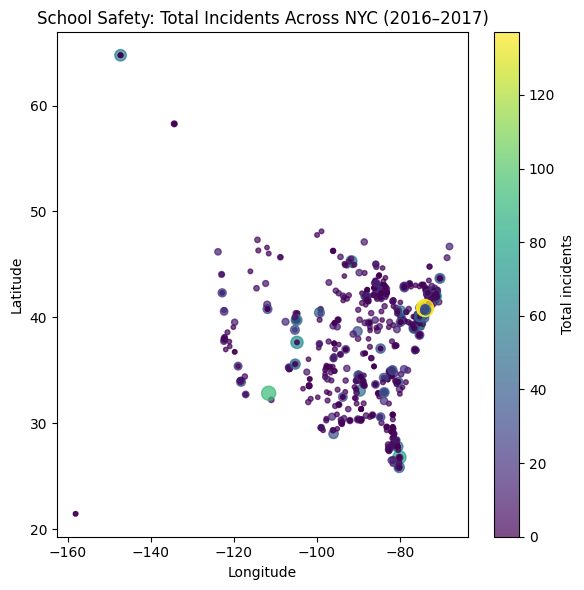

In [30]:
# 10. Scatter plot of school locations colored by total incidents

plt.figure(figsize=(6, 6))

sc = plt.scatter(
    df_map["lon"],
    df_map["lat"],
    c=df_map["total_incidents"],
    s=10 + df_map["total_incidents"],  # slightly larger for more incidents
    alpha=0.7
)

plt.colorbar(sc, label="Total incidents")
plt.title("School Safety: Total Incidents Across NYC (2016–2017)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()
plt.show()


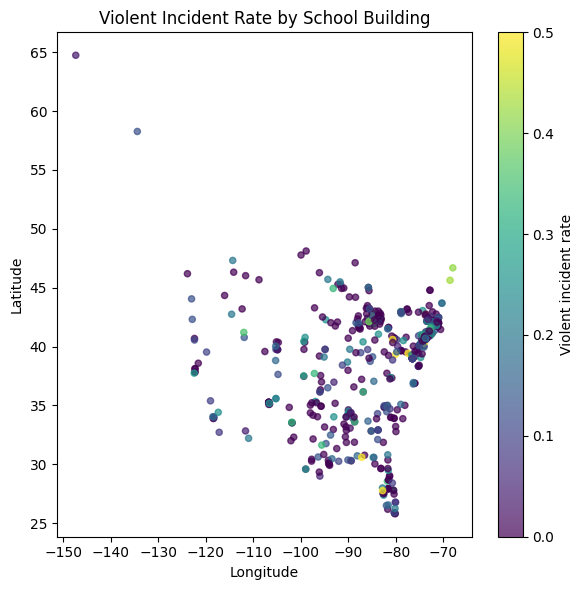

In [31]:
# 11. Scatter plot colored by violent incident rate

df_map_rate = df_map.dropna(subset=["violent_rate"]).copy()

plt.figure(figsize=(6, 6))

sc = plt.scatter(
    df_map_rate["lon"],
    df_map_rate["lat"],
    c=df_map_rate["violent_rate"],
    s=20,
    alpha=0.7
)

plt.colorbar(sc, label="Violent incident rate")
plt.title("Violent Incident Rate by School Building")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()
plt.show()


**Evaluation of Hypotheses**

**Hypothesis 1: Borough differences exist.**

Supported. Brooklyn and the Bronx show higher volume and higher rates of incidents.

**Hypothesis 2: Shared buildings have more incidents.**

Partially supported.
Although noisy, the average trend increases as the number of schools in a building increases.

**Hypothesis 3: Safety outcomes are geographically clustered.**
Supported.
Maps reveal clear clusters in the Bronx and Brooklyn.

**Conclusion**

School safety in New York City is unevenly distributed across boroughs, buildings, and neighborhoods.
Brooklyn and the Bronx face higher overall incident counts, while Manhattan and Queens show moderate levels, and Staten Island remains comparatively safe.

Multiple-school buildings tend to report higher incidents, suggesting that density and shared resources contribute to conflict.
Geospatial visualization highlights specific high-risk neighborhoods, indicating potential areas for targeted intervention.

Overall, this project demonstrates how public administrative data can be transformed, aggregated, and visualized to reveal meaningful insights about school safety across NYC.